# E2 Latent Steering Experiment

Tests whether steering L2 encoder states toward English improves WER.
Validates core hypothesis before investing in diffusion training.

In [24]:
import torch
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import jiwer

ROOT = Path("/rds/general/user/tsv22/home/accent-robust-asr")
sys.path.insert(0, str(ROOT))

from src.config import TEST_SPEAKERS, SPEAKER_L1
from src.training.evaluation.eval_whisfusion import WhisfusionWrapper

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    !nvidia-smi

Device: cuda
GPU: NVIDIA A40
Fri May 15 15:37:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:B1:00.0 Off |                    0 |
|  0%   38C    P0             76W /  300W |    4393MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------

In [25]:
import re


def load_checkpoint(path: str) -> np.ndarray:
    """Load encoder state from .pt file, return as float32 numpy array."""
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    hidden_states = checkpoint["hidden_states"]
    if isinstance(hidden_states, torch.Tensor):
        return hidden_states.to(torch.float32).cpu().numpy()
    return np.array(hidden_states, dtype=np.float32)

def norm(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", "", s)  # Remove punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s

def build_reference_lookup(wer_csv: str) -> dict:
    """Load reference text data and build lookup dict: (prompt_id, speaker) -> reference_text"""
    wer_df = pd.read_csv(wer_csv)

    # Identify columns
    prompt_col = next((c for c in ["utterance_id", "prompt_id", "utt_id"] if c in wer_df.columns), None)
    speaker_col = next((c for c in ["speaker", "spk"] if c in wer_df.columns), None)
    ref_col = next((c for c in ["reference_norm", "reference", "text"] if c in wer_df.columns), None)

    if not all([prompt_col, speaker_col, ref_col]):
        raise ValueError(f"Could not identify columns. Found: {list(wer_df.columns)}")

    # Build lookup
    ref_data = {}
    for _, row in wer_df.iterrows():
        key = (str(row[prompt_col]), str(row[speaker_col]))
        value = str(row[ref_col]).strip()
        if pd.notna(value) and len(value) > 0:
            ref_data[key] = value

    return ref_data

def subsample_utterances(mapping: dict, num_utts: int = None) -> dict:
    """Subsample mapping to keep only N utterances (prompts).

    Args:
        mapping: Full utterance mapping dict
        num_utts: If None, keep all. If int, randomly sample this many prompts.

    Returns:
        Subsampled mapping
    """
    if num_utts is None:
        return mapping

    prompts = list(mapping.keys())
    sampled_prompts = np.random.choice(prompts, size=min(num_utts, len(prompts)), replace=False)
    
    # Filter mapping to only include sampled prompts
    subsampled = {pid: mapping[pid] for pid in sampled_prompts}
    return subsampled

print("✓ Functions defined")

✓ Functions defined


In [26]:
# Load data
mapping_cache = ROOT / "src/analysis/cache/utterance_mapping.json"
wer_csv = ROOT / "results/model_perf_comparison/whisfusion_finetuned_predictions.csv"
output_dir = ROOT / "src/analysis/results/e2_steering"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Loading utterance mapping from {mapping_cache}...")
with open(mapping_cache) as f:
    mapping = json.load(f)
print(f"  Loaded {len(mapping)} prompts")

print(f"Loading reference text from {wer_csv}...")
ref_data = build_reference_lookup(str(wer_csv))
print(f"  Loaded reference text for {len(ref_data)} (prompt, speaker) pairs")

# Build selected speakers (test speakers only - BDL is English reference)
selected_speakers = {SPEAKER_L1[spk]: spk for spk in TEST_SPEAKERS}
print(f"\nSelected speakers: {selected_speakers}")

Loading utterance mapping from /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/cache/utterance_mapping.json...
  Loaded 1132 prompts
Loading reference text from /rds/general/user/tsv22/home/accent-robust-asr/results/model_perf_comparison/whisfusion_finetuned_predictions.csv...
  Loaded reference text for 7796 (prompt, speaker) pairs

Selected speakers: {'English': 'BDL', 'Hindi': 'SVBI', 'Vietnamese': 'HQTV', 'Chinese': 'BWC', 'Spanish': 'EBVS', 'Arabic': 'ZHAA', 'Korean': 'HJK'}


In [27]:
# ===== SUBSAMPLING CONTROL - change this to iterate faster =====
NUM_UTTERANCES = 100  # Set to None for full dataset, or any integer (e.g., 10, 50, 100)
# ================================================================

original_mapping_size = len(mapping)
mapping = subsample_utterances(mapping, num_utts=NUM_UTTERANCES)

if NUM_UTTERANCES is not None:
    print(f"\n🔍 SUBSAMPLED: {original_mapping_size} → {len(mapping)} prompts ({len(mapping)/original_mapping_size*100:.1f}%)")
    print(f"   Testing {len(mapping)} utterances × 6 L1 speakers")
else:
    print(f"\n✓ Using full dataset: {len(mapping)} prompts")


🔍 SUBSAMPLED: 1132 → 100 prompts (8.8%)
   Testing 100 utterances × 6 L1 speakers


In [28]:
# Load model
print(f"\nLoading Whisfusion model on {device}...")
base_model = ROOT / "models/smdm/mdm_safetensors/mdm-170M-100e18-rsl-0.01.safetensors"
adapter_path = ROOT / "models/whisfusion_finetuned/stage2_decoder/whisfusion_stage2_decoder.pt"

if not base_model.exists():
    raise FileNotFoundError(f"Base model not found: {base_model}")
if not adapter_path.exists():
    raise FileNotFoundError(f"Adapter not found: {adapter_path}")

wrapper = WhisfusionWrapper(
    base_model_path=str(base_model),
    adapter_path=str(adapter_path),
    device=device,
)
print(f"  ✓ Model loaded on {device}")


Loading Whisfusion model on cuda...
Loading Whisfusion model...


/rds/general/user/tsv22/home/accent-robust-asr/models/whisfusion/src/evaluation/evaluate_whisfusion.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  adapter_weights = t

Loading tokenizer...
✅ Whisfusion loaded: 261.5M parameters

Warming up Whisfusion...


Warmup: 100%|██████████| 2/2 [00:00<00:00, 61.86iter/s]

✅ Warmup complete!
  ✓ Model loaded on cuda


In [29]:
# After loading eng_state and l2_state for a few examples, print:
prompts = list(mapping.keys())
for prompt_id in prompts[:5]:
    l1_dict = mapping[prompt_id]
    eng_path = l1_dict["English"]["path"]
    l2_path = l1_dict["Hindi"]["path"]  # Pick one L1

    eng_state = load_checkpoint(eng_path)
    l2_state = load_checkpoint(l2_path)

    print(f"\nPrompt {prompt_id}:")
    print(f"  Eng shape: {eng_state.shape}, mean: {eng_state.mean():.4f}, std: {eng_state.std():.4f}")
    print(f"  L2 shape: {l2_state.shape}, mean: {l2_state.mean():.4f}, std: {l2_state.std():.4f}")
    print(f"  Shapes match: {eng_state.shape == l2_state.shape}")

    # Test decode at alpha=0 and alpha=1
    eng_decoded = wrapper.decode(torch.from_numpy(eng_state).to(device))
    l2_decoded = wrapper.decode(torch.from_numpy(l2_state).to(device))

    ref = ref_data.get((prompt_id, "BDL"))  # Use BDL for English
    ref_norm = norm(ref) if ref else ""
    
    print(f"  Reference: {ref_norm}")
    
    # Compute WER for English (alpha=1.0)
    eng_pred_norm = norm(eng_decoded)
    eng_wer = jiwer.wer(ref_norm, eng_pred_norm) if ref_norm else None
    print(f"  α=1.0 (English) prediction: {eng_pred_norm}")
    print(f"    WER: {eng_wer:.4f}" if eng_wer is not None else "    WER: N/A")
    
    # Compute WER for L2 (alpha=0.0)
    l2_pred_norm = norm(l2_decoded)
    l2_wer = jiwer.wer(ref_norm, l2_pred_norm) if ref_norm else None
    print(f"  α=0.0 (L2) prediction: {l2_pred_norm}")
    print(f"    WER: {l2_wer:.4f}" if l2_wer is not None else "    WER: N/A")
    
    if eng_wer is not None and l2_wer is not None:
        delta = eng_wer - l2_wer
        print(f"  Δ WER (Eng - L2): {delta:+.4f}")


Prompt arctic_a0391:
  Eng shape: (1500, 768), mean: -0.0086, std: 1.6176
  L2 shape: (1500, 768), mean: -0.0091, std: 1.6079
  Shapes match: True
  Reference: but he reconciled himself to it by an act of faith
  α=1.0 (English) prediction: but he reconciled himself to it by an act of faith
    WER: 0.0000
  α=0.0 (L2) prediction: but he reconciled himself to it an act of faith
    WER: 0.0909
  Δ WER (Eng - L2): -0.0909

Prompt arctic_b0374:
  Eng shape: (1500, 768), mean: -0.0090, std: 1.6282
  L2 shape: (1500, 768), mean: -0.0090, std: 1.6173
  Shapes match: True
  Reference: to say the least captain cook was a rather thorough going empiricist
  α=1.0 (English) prediction: to say the least captain cook was a rather thorough going going empiricist
    WER: 0.0833
  α=0.0 (L2) prediction: to say the least captain cook was a rather thorough going empirist
    WER: 0.0833
  Δ WER (Eng - L2): +0.0000

Prompt arctic_a0508:
  Eng shape: (1500, 768), mean: -0.0090, std: 1.6390
  L2 shape: 

In [30]:
# Inspect padding: what's in the embedding space after speech_end_frame?
print("Inspecting padding structure in encoder states...\n")

sample_prompt = list(mapping.keys())[0]
l1_dict = mapping[sample_prompt]

# Get speech_end_frame from mapping (if available)
eng_speech_end = l1_dict["English"].get("speech_end_frame")
l2_speech_end = l1_dict["Hindi"].get("speech_end_frame")

eng_state = load_checkpoint(l1_dict["English"]["path"])
l2_state = load_checkpoint(l1_dict["Hindi"]["path"])

print(f"Sample: {sample_prompt}")
print(f"English: speech_end_frame={eng_speech_end}, total shape={eng_state.shape}")
print(f"Hindi:   speech_end_frame={l2_speech_end}, total shape={l2_state.shape}\n")

if eng_speech_end:
    print(f"English padding region analysis (frames {eng_speech_end}-1500):")
    padding_eng = eng_state[eng_speech_end:]
    print(f"  Shape: {padding_eng.shape}")
    print(f"  Mean: {padding_eng.mean():.6f}, Std: {padding_eng.std():.6f}")
    print(f"  Min: {padding_eng.min():.6f}, Max: {padding_eng.max():.6f}")
    print(f"  All zeros? {np.allclose(padding_eng, 0)}")
    print(f"  Unique values (first 5): {np.unique(padding_eng.flatten())[:5]}")
    
    print(f"\nEnglish speech region analysis (frames 0-{eng_speech_end}):")
    speech_eng = eng_state[:eng_speech_end]
    print(f"  Shape: {speech_eng.shape}")
    print(f"  Mean: {speech_eng.mean():.6f}, Std: {speech_eng.std():.6f}")
    print(f"  Min: {speech_eng.min():.6f}, Max: {speech_eng.max():.6f}")

if l2_speech_end:
    print(f"\nHindi padding region analysis (frames {l2_speech_end}-1500):")
    padding_l2 = l2_state[l2_speech_end:]
    print(f"  Shape: {padding_l2.shape}")
    print(f"  Mean: {padding_l2.mean():.6f}, Std: {padding_l2.std():.6f}")
    print(f"  Min: {padding_l2.min():.6f}, Max: {padding_l2.max():.6f}")
    print(f"  All zeros? {np.allclose(padding_l2, 0)}")
    
    print(f"\nHindi speech region analysis (frames 0-{l2_speech_end}):")
    speech_l2 = l2_state[:l2_speech_end]
    print(f"  Shape: {speech_l2.shape}")
    print(f"  Mean: {speech_l2.mean():.6f}, Std: {speech_l2.std():.6f}")
    print(f"  Min: {speech_l2.min():.6f}, Max: {speech_l2.max():.6f}")

Inspecting padding structure in encoder states...

Sample: arctic_a0391
English: speech_end_frame=164, total shape=(1500, 768)
Hindi:   speech_end_frame=135, total shape=(1500, 768)

English padding region analysis (frames 164-1500):
  Shape: (1336, 768)
  Mean: -0.008259, Std: 1.625161
  Min: -32.250000, Max: 26.250000
  All zeros? False
  Unique values (first 5): [-32.25  -31.75  -31.5   -31.375 -31.25 ]

English speech region analysis (frames 0-164):
  Shape: (164, 768)
  Mean: -0.010936, Std: 1.554469
  Min: -20.250000, Max: 18.750000

Hindi padding region analysis (frames 135-1500):
  Shape: (1365, 768)
  Mean: -0.009259, Std: 1.615191
  Min: -32.500000, Max: 27.125000
  All zeros? False

Hindi speech region analysis (frames 0-135):
  Shape: (135, 768)
  Mean: -0.007617, Std: 1.531867
  Min: -21.750000, Max: 18.750000


In [31]:
# Run steering experiment (with caching)
alpha_values = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]
results_path = output_dir / "steering_results.csv"

output_dir.mkdir(parents=True, exist_ok=True)

# Check cache
if results_path.exists():
    print(f"Loading cached position-based results from {results_path}...")
    results_df = pd.read_csv(results_path)
    results = results_df.to_dict('records')
    print(f"✓ Loaded {len(results_df)} cached results")
else:
    print("No cache found. Running position-based steering experiment...")
    results = []

    prompts = sorted(mapping.keys())
    print(f"\nProcessing {len(prompts)} prompts x {len(alpha_values)} alpha values...")
    total_decodes = len(prompts) * 6 * len(alpha_values)
    print(f"Total decode calls: {total_decodes}\n")

    decode_count = 0
    for prompt_idx, prompt_id in enumerate(prompts):
        l1_dict = mapping[prompt_id]

        # Skip if no English reference
        if "English" not in l1_dict:
            continue

        # Load English reference state
        eng_path = l1_dict["English"]["path"]
        if not Path(eng_path).exists():
            continue

        try:
            eng_state = load_checkpoint(eng_path)
            eng_state_torch = torch.from_numpy(eng_state).to(device)
        except Exception as e:
            print(f"  [ERROR] Failed to load English {prompt_id}: {e}")
            continue

        # Test each L1 speaker
        for l1, speaker_info in l1_dict.items():
            if l1 == "English":
                continue

            speaker = speaker_info["speaker"]
            l2_path = speaker_info["path"]

            if not Path(l2_path).exists():
                continue

            try:
                l2_state = load_checkpoint(l2_path)
                l2_state_torch = torch.from_numpy(l2_state).to(device)
            except Exception as e:
                print(f"  [ERROR] Failed to load L2 {prompt_id}/{l1}: {e}")
                continue

            # Get reference text
            reference = ref_data.get((prompt_id, speaker))
            if reference is None:
                continue

            # Test each alpha value
            for alpha in alpha_values:
                # Interpolate: steered = α * eng + (1-α) * l2
                steered_state = alpha * eng_state_torch + (1 - alpha) * l2_state_torch

                try:
                    # Decode with steered state
                    prediction = wrapper.decode(steered_state)

                    # Compute WER
                    wer_score = jiwer.wer(norm(reference), norm(prediction))

                    results.append({
                        "prompt_id": prompt_id,
                        "L1": l1,
                        "speaker": speaker,
                        "alpha": alpha,
                        "wer": wer_score,
                    })

                except Exception as e:
                    print(f"  [ERROR] Decode/WER failed {prompt_id}/{l1}/α={alpha}: {e}")
                
                # Only count actual decodes
                decode_count += 1
                # Print progress every ~10% of total
                if decode_count % max(1, total_decodes // 10) == 0:
                    pct = 100 * decode_count / total_decodes
                    print(f"  [{pct:3.0f}%] {decode_count}/{total_decodes} | {speaker} α={alpha:.2f}", flush=True)

    print(f"\n✓ Computed WER for {len(results)} utterances")
    
    # Save to cache
    results_df = pd.DataFrame(results)
    results_df.to_csv(results_path, index=False)
    print(f"✓ Saved results to cache: {results_path}")

print(f"\nResults shape: {results_df.shape}")
print(f"Alpha values: {sorted(results_df['alpha'].unique())}")
print(f"L1s: {sorted(results_df['L1'].unique())}")
print(f"\nWER stats:")
print(results_df.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

Loading cached position-based results from /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results.csv...
✓ Loaded 2960 cached results

Results shape: (2960, 5)
Alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
L1s: ['Arabic', 'Chinese', 'Hindi', 'Korean', 'Spanish', 'Vietnamese']

WER stats:
         mean     std  min     max
alpha                             
0.00   0.0900  0.1446  0.0  0.8333
0.25   0.1743  0.1511  0.0  0.7000
0.50   0.2836  0.2036  0.0  0.9000
0.75   0.1492  0.1370  0.0  0.8000
1.00   0.0400  0.0901  0.0  0.6667


In [32]:
# Results are now cached in steering_results.csv (saved in cell above)
print(f"✓ Position-based results cached at: {results_path}")
print(f"  (Delete {results_path} to force recomputation)")

✓ Position-based results cached at: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results.csv
  (Delete /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results.csv to force recomputation)


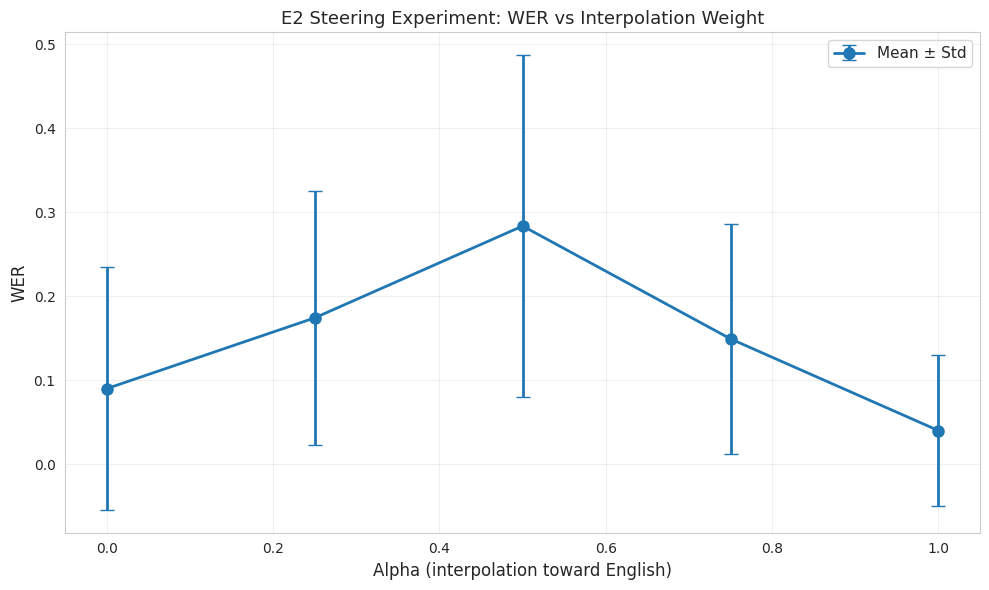

✓ Saved plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_wer_vs_alpha.png


In [13]:
# Visualize: WER vs alpha (overall)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean WER by alpha
alpha_stats = results_df.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'], 
            fmt='o-', linewidth=2, markersize=8, capsize=5, label='Mean ± Std')

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER', fontsize=12)
ax.set_title('E2 Steering Experiment: WER vs Interpolation Weight', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(output_dir / 'steering_wer_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved plot to {output_dir / 'steering_wer_vs_alpha.png'}")

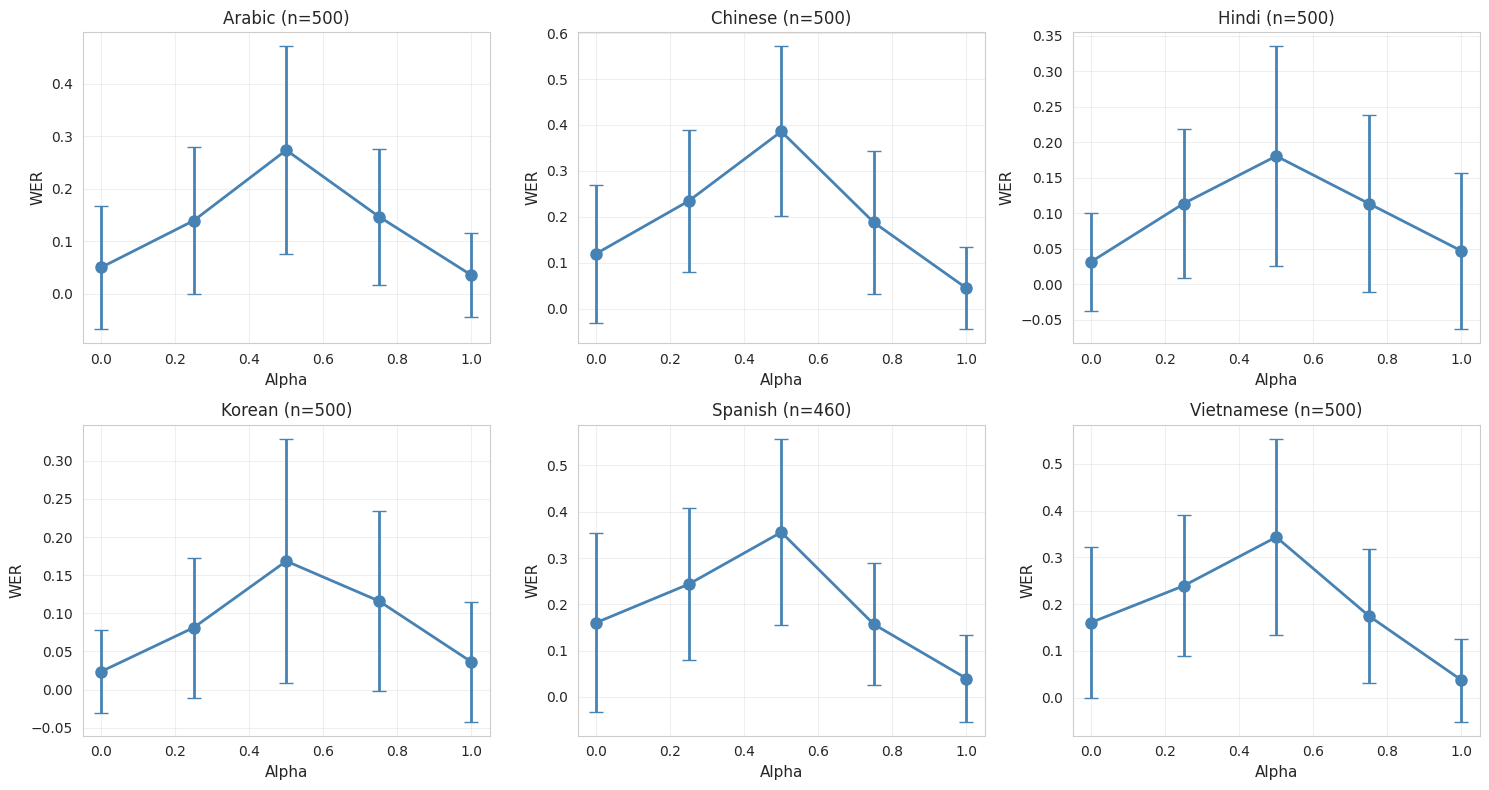

✓ Saved per-L1 plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_wer_per_l1.png


In [14]:
# Visualize: WER vs alpha per L1
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, l1 in enumerate(sorted(results_df['L1'].unique())):
    ax = axes[idx]
    subset = results_df[results_df['L1'] == l1]
    
    alpha_stats = subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
    ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                fmt='o-', linewidth=2, markersize=8, capsize=5, color='steelblue')
    
    ax.set_xlabel('Alpha', fontsize=11)
    ax.set_ylabel('WER', fontsize=11)
    ax.set_title(f'{l1} (n={len(subset)})', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'steering_wer_per_l1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved per-L1 plot to {output_dir / 'steering_wer_per_l1.png'}")

In [33]:
# ===== WARP L2 TO ENGLISH TIMELINE (DTW-BASED) =====
# DTW alignment but keep English intact; warp L2 onto English timeline

import time
from dtaidistance import dtw_ndim

def warp_l2_to_english_timeline(eng_state: np.ndarray, l2_state: np.ndarray, alpha: float) -> np.ndarray:
    """
    DTW-align then warp L2 onto English timeline (keep English intact).
    
    Args:
        eng_state: English encoder state, trimmed to speech (T_eng, 768)
        l2_state: L2 encoder state, trimmed to speech (T_l2, 768)
        alpha: Interpolation weight (0=pure L2, 1=pure English)
    
    Returns:
        Steered state on English timeline (T_eng, 768)
    """
    # Compute DTW warping path
    path = dtw_ndim.warping_path(eng_state, l2_state)
    path_array = np.array(path)
    
    # Accumulate L2 frames onto English time axis
    l2_aligned = np.zeros_like(eng_state)
    counts = np.zeros(len(eng_state))
    
    for i, j in path_array:
        l2_aligned[i] += l2_state[j]
        counts[i] += 1
    
    # Average where multiple L2 frames map to one English frame
    l2_aligned /= counts[:, None]
    
    # Interpolate: steered = α * eng + (1-α) * l2_aligned
    steered = alpha * eng_state + (1 - alpha) * l2_aligned
    
    return steered


def pad_to_1500_with_english(steered_state: np.ndarray, eng_state_full: np.ndarray, eng_speech_end: int) -> np.ndarray:
    """
    Pad steered state back to 1500 frames using English padding.
    
    Args:
        steered_state: Interpolated state on English timeline (T_eng, 768)
        eng_state_full: Full English state including padding (1500, 768)
        eng_speech_end: Frame index where English speech ends
    
    Returns:
        Padded state (1500, 768)
    """
    target_len = 1500
    steered_len = len(steered_state)
    
    if steered_len >= target_len:
        return steered_state[:target_len]
    
    # Use English padding for all interpolations
    eng_padding = eng_state_full[eng_speech_end:]
    padding_needed = target_len - steered_len
    
    if len(eng_padding) >= padding_needed:
        padding = eng_padding[:padding_needed]
    else:
        # Fallback: replicate last frame if not enough
        padding = eng_padding
        remaining = padding_needed - len(padding)
        if remaining > 0:
            padding = np.vstack([padding, np.tile(eng_padding[-1:], (remaining, 1))])
    
    padded = np.vstack([steered_state, padding])
    
    return padded.astype(np.float32)


print("✓ Warp-L2-to-English functions defined")

✓ Warp-L2-to-English functions defined


In [34]:
# Verify mapping has speech_end_frame; rebuild if needed
sample_prompt = list(mapping.keys())[0]
sample_l1_dict = mapping[sample_prompt]

has_speech_end_frame = any("speech_end_frame" in info for info in sample_l1_dict.values())

if not has_speech_end_frame:
    print("Rebuilding mapping with speech_end_frame info...")
    from src.utils.textgrid import parse_textgrid
    
    # Helper to parse CMU LAB files
    def parse_lab_file(lab_path: str):
        segments = []
        with open(lab_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        start_time = float(parts[0])
                        phone_label = parts[2]
                        if phone_label.lower() != 'pau':
                            segments.append((start_time, phone_label))
                    except (ValueError, IndexError):
                        continue
        
        if not segments:
            return None
        
        phone_segments = []
        for i, (start, label) in enumerate(segments):
            end = segments[i+1][0] if i+1 < len(segments) else start + 0.1
            phone_segments.append({'label': label.upper(), 'start': start, 'end': end})
        
        return phone_segments
    
    # Rebuild with speech_end_frame
    L2ARCTIC_ABS = ROOT / "data" / "l2_arctic"
    CMU_ARCTIC_ABS = ROOT / "data" / "cmu_arctic"
    
    for prompt_id in mapping.keys():
        l1_dict = mapping[prompt_id]
        for l1, info in l1_dict.items():
            if "speech_end_frame" in info:
                continue
            
            # Determine path based on L1
            if l1 == "English":
                speaker = info["speaker"]
                lab_path = CMU_ARCTIC_ABS / f"cmu_us_{speaker.lower()}_arctic" / "lab" / f"{prompt_id}.lab"
                if lab_path.exists():
                    try:
                        segments = parse_lab_file(str(lab_path))
                        if segments:
                            speech_end_frame = int(segments[-1]['end'] * 50) + 1
                            info["speech_end_frame"] = speech_end_frame
                    except Exception:
                        pass
            else:
                speaker = info["speaker"]
                tg_path = L2ARCTIC_ABS / speaker / "textgrid" / f"{prompt_id}.TextGrid"
                if tg_path.exists():
                    try:
                        segments = parse_textgrid(str(tg_path), tier_name='phones')
                        if segments:
                            speech_end_frame = int(segments[-1].end * 50) + 1
                            info["speech_end_frame"] = speech_end_frame
                    except Exception:
                        pass
    
    print("✓ Mapping rebuilt with speech_end_frame")
else:
    print("✓ Mapping already has speech_end_frame info")

# Check coverage
missing_count = sum(1 for l1d in mapping.values() for info in l1d.values() if "speech_end_frame" not in info)
print(f"  Entries with speech_end_frame: {sum(len(l1d) for l1d in mapping.values()) - missing_count}/{sum(len(l1d) for l1d in mapping.values())}")


✓ Mapping already has speech_end_frame info
  Entries with speech_end_frame: 685/685


In [35]:
# Run DTW-aligned steering experiment with L2 warped to English timeline (with caching)
alpha_values = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]
dtw_results_path = output_dir / "steering_results_dtw_aligned.csv"

# Check cache
if dtw_results_path.exists():
    print(f"Loading cached DTW-aligned results from {dtw_results_path}...")
    results_dtw_df = pd.read_csv(dtw_results_path)
    results_dtw = results_dtw_df.to_dict('records')
    print(f"✓ Loaded {len(results_dtw_df)} cached DTW results")
else:
    print("No DTW cache found. Running DTW-aligned steering experiment (L2 warped to English timeline)...")
    results_dtw = []

    prompts = sorted(mapping.keys())
    total_items = len(prompts) * 6 * len(alpha_values)
    
    with tqdm(total=total_items, desc="DTW Steering (L2→English)", unit="decode") as pbar:
        for prompt_idx, prompt_id in enumerate(prompts):
            l1_dict = mapping[prompt_id]

            # Skip if no English reference
            if "English" not in l1_dict:
                continue

            # Load English reference state
            eng_path = l1_dict["English"]["path"]
            eng_speech_end = l1_dict["English"].get("speech_end_frame")
            
            if not Path(eng_path).exists() or not eng_speech_end:
                pbar.update(6 * len(alpha_values))  # Skip all alphas for all L1s
                continue

            try:
                eng_state_full = load_checkpoint(eng_path)
                eng_state = eng_state_full[:eng_speech_end]  # Trim to speech
            except Exception as e:
                pbar.update(6 * len(alpha_values))
                continue

            # Test each L1 speaker
            for l1, speaker_info in l1_dict.items():
                if l1 == "English":
                    continue

                speaker = speaker_info["speaker"]
                l2_path = speaker_info["path"]
                l2_speech_end = speaker_info.get("speech_end_frame")

                if not Path(l2_path).exists() or not l2_speech_end:
                    pbar.update(len(alpha_values))
                    continue

                try:
                    l2_state_full = load_checkpoint(l2_path)
                    l2_state = l2_state_full[:l2_speech_end]  # Trim to speech
                except Exception as e:
                    pbar.update(len(alpha_values))
                    continue

                # Get reference text
                reference = ref_data.get((prompt_id, speaker))
                if reference is None:
                    pbar.update(len(alpha_values))
                    continue

                # Test each alpha value
                for alpha in alpha_values:
                    try:
                        # Warp L2 to English timeline and interpolate
                        steered_aligned = warp_l2_to_english_timeline(eng_state, l2_state, alpha)
                        
                        # Pad back to 1500 using English padding
                        steered_state = pad_to_1500_with_english(steered_aligned, eng_state_full, eng_speech_end)
                        
                        # Decode with steered state
                        steered_torch = torch.from_numpy(steered_state).to(device)
                        prediction = wrapper.decode(steered_torch)

                        # Compute WER
                        wer_score = jiwer.wer(norm(reference), norm(prediction))

                        results_dtw.append({
                            "prompt_id": prompt_id,
                            "L1": l1,
                            "speaker": speaker,
                            "alpha": alpha,
                            "wer": wer_score,
                            "method": "dtw_aligned",
                        })

                    except Exception as e:
                        pass
                    
                    pbar.update(1)

    print(f"✓ Computed DTW-aligned WER for {len(results_dtw)} utterances")
    
    # Save to cache
    results_dtw_df = pd.DataFrame(results_dtw)
    results_dtw_df.to_csv(dtw_results_path, index=False)
    print(f"✓ Saved DTW results to cache: {dtw_results_path}")

print(f"\nDTW results shape: {results_dtw_df.shape}")
print(f"Alpha values: {sorted(results_dtw_df['alpha'].unique())}")
print(f"L1s: {sorted(results_dtw_df['L1'].unique())}")
print(f"\nDTW WER stats:")
print(results_dtw_df.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

Loading cached DTW-aligned results from /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results_dtw_aligned.csv...
✓ Loaded 3546 cached DTW results

DTW results shape: (3546, 6)
Alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]
L1s: ['Arabic', 'Chinese', 'Hindi', 'Korean', 'Spanish', 'Vietnamese']

DTW WER stats:
         mean     std  min    max
alpha                            
0.00   0.1461  0.1619  0.0  0.800
0.25   0.0991  0.1280  0.0  1.000
0.50   0.0807  0.1140  0.0  0.750
0.75   0.0617  0.0964  0.0  0.625
0.90   0.0689  0.1155  0.0  0.625
1.00   0.0709  0.1182  0.0  0.800


In [ ]:
print("="*70)
print("OVERALL WER by Alpha")
print("="*70)
print(results_dtw_df.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

print("\n\n\n")

print("="*70)
print("PER-L1 WER by Alpha")
print("="*70)
for l1 in sorted(results_dtw_df['L1'].unique()):
    l1_subset = results_dtw_df[results_dtw_df['L1'] == l1]
    print(f"\n{l1}:")
    print(l1_subset.groupby('alpha')['wer'].agg(['mean', 'std']).round(4))
print("✓ Updated cell 14 to print overall and per-L1 WER breakdowns by alpha")

OVERALL WER by Alpha
         mean     std  min    max
alpha                            
0.00   0.1461  0.1619  0.0  0.800
0.25   0.0991  0.1280  0.0  1.000
0.50   0.0807  0.1140  0.0  0.750
0.75   0.0617  0.0964  0.0  0.625
0.90   0.0689  0.1155  0.0  0.625
1.00   0.0709  0.1182  0.0  0.800




PER-L1 WER by Alpha

Arabic:
         mean     std
alpha                
0.00   0.1181  0.1470
0.25   0.0854  0.1263
0.50   0.0685  0.0998
0.75   0.0613  0.0893
0.90   0.0701  0.1223
1.00   0.0638  0.1073

Chinese:
         mean     std
alpha                
0.00   0.1803  0.1652
0.25   0.1237  0.1210
0.50   0.0895  0.1037
0.75   0.0659  0.0926
0.90   0.0720  0.1168
1.00   0.0778  0.1218

Hindi:
         mean     std
alpha                
0.00   0.0699  0.0962
0.25   0.0598  0.1251
0.50   0.0622  0.1108
0.75   0.0623  0.0909
0.90   0.0697  0.1108
1.00   0.0676  0.1243

Korean:
         mean     std
alpha                
0.00   0.0628  0.1019
0.25   0.0514  0.0914
0.50   0.0540  0.1032
0.75   0.

In [36]:
# Compute WER delta (normalized improvement from L2 baseline) for all methods
print("Computing WER delta (normalized against L2 baseline per utterance)...\n")

# For each utterance, compute the L2 baseline WER (alpha=0.0)
def compute_wer_delta(results_df):
    """
    Compute WER_delta = WER_L2_baseline - WER_current for normalization.
    Positive delta means improvement from steering; negative means worse than L2.
    """
    # Get L2 baseline WER per utterance
    l2_baselines = results_df[results_df['alpha'] == 0.0][['prompt_id', 'L1', 'speaker', 'wer']].copy()
    l2_baselines.columns = ['prompt_id', 'L1', 'speaker', 'wer_l2_baseline']
    
    # Merge back to get delta for all alphas
    results_with_delta = results_df.merge(l2_baselines, on=['prompt_id', 'L1', 'speaker'], how='left')
    results_with_delta['wer_delta'] = results_with_delta['wer_l2_baseline'] - results_with_delta['wer']
    
    return results_with_delta

# Compute deltas
results_df_delta = compute_wer_delta(results_df)
results_dtw_df_delta = compute_wer_delta(results_dtw_df)

print(f"Position-based: WER delta stats")
print(results_df_delta.groupby('alpha')['wer_delta'].agg(['mean', 'std', 'min', 'max']).round(4))

print(f"\nDTW-aligned: WER delta stats")
print(results_dtw_df_delta.groupby('alpha')['wer_delta'].agg(['mean', 'std', 'min', 'max']).round(4))

print(f"\n✓ WER delta computed for all results")

Computing WER delta (normalized against L2 baseline per utterance)...

Position-based: WER delta stats
         mean     std     min     max
alpha                                
0.00   0.0000  0.0000  0.0000  0.0000
0.25  -0.0843  0.1431 -0.5714  0.5000
0.50  -0.1936  0.2135 -0.8462  0.5000
0.75  -0.0592  0.1739 -0.6000  0.8333
1.00   0.0500  0.1587 -0.6667  0.8333

DTW-aligned: WER delta stats
         mean     std     min  max
alpha                             
0.00   0.0000  0.0000  0.0000  0.0
0.25   0.0470  0.1225 -0.6667  0.6
0.50   0.0654  0.1452 -0.3750  0.8
0.75   0.0844  0.1682 -0.6000  0.8
0.90   0.0772  0.1863 -0.6000  0.8
1.00   0.0752  0.1875 -0.8000  0.8

✓ WER delta computed for all results


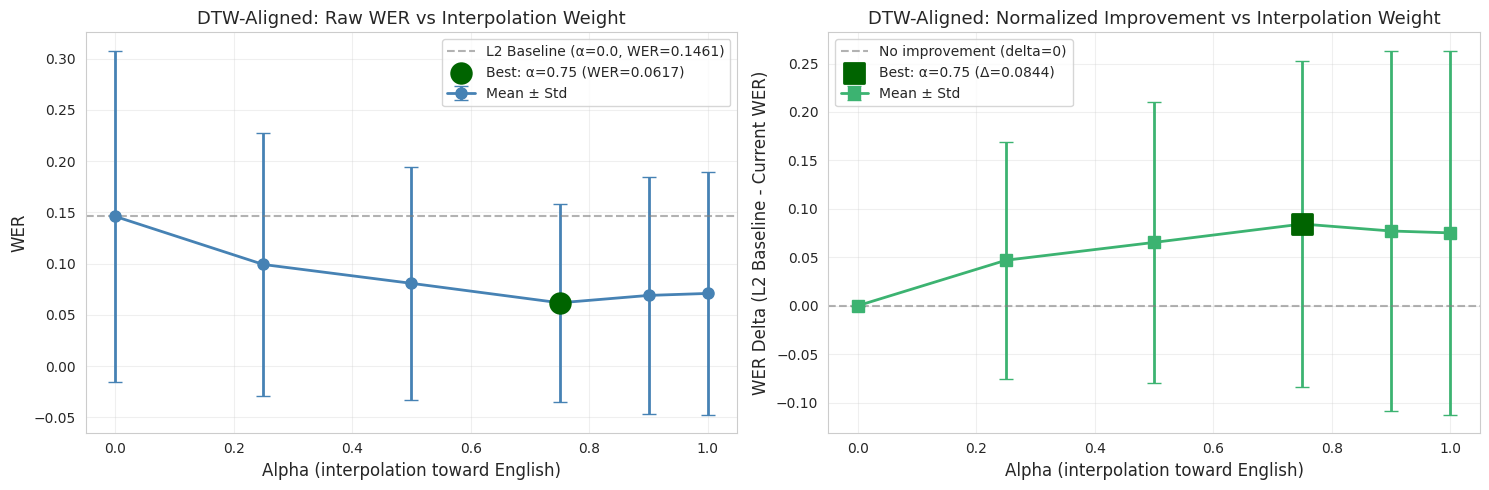

✓ Saved DTW raw WER + delta plots to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_dtw_raw_and_delta.png


In [41]:
# Visualize: DTW WER vs alpha (overall) with L2 baseline line + WER delta
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ===== RAW WER =====
ax = axes[0]
alpha_stats = results_dtw_df_delta.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
alpha_stats = alpha_stats.sort_values('alpha')
ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'], 
            fmt='o-', linewidth=2, markersize=8, capsize=5, label='Mean ± Std', color='steelblue')

# Add subtle horizontal line at L2 baseline
l2_baseline_wer = alpha_stats[alpha_stats['alpha'] == 0.0]['mean'].values[0]
ax.axhline(l2_baseline_wer, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label=f'L2 Baseline (α=0.0, WER={l2_baseline_wer:.4f})')

# Highlight best (lowest WER) point
best_idx = alpha_stats['mean'].idxmin()
best_alpha = alpha_stats.loc[best_idx, 'alpha']
best_wer = alpha_stats.loc[best_idx, 'mean']
ax.scatter([best_alpha], [best_wer], s=200, marker='o', color='darkgreen', 
           linewidth=2, edgecolor='darkgreen', zorder=5, label=f'Best: α={best_alpha:.2f} (WER={best_wer:.4f})')

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER', fontsize=12)
ax.set_title('DTW-Aligned: Raw WER vs Interpolation Weight', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# ===== WER DELTA =====
ax = axes[1]
delta_stats = results_dtw_df_delta.groupby('alpha')['wer_delta'].agg(['mean', 'std']).reset_index()
delta_stats = delta_stats.sort_values('alpha')
ax.errorbar(delta_stats['alpha'], delta_stats['mean'], yerr=delta_stats['std'], 
            fmt='s-', linewidth=2, markersize=8, capsize=5, label='Mean ± Std', color='mediumseagreen')

# Add zero line (no improvement)
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='No improvement (delta=0)')

# Highlight best (highest delta) point
best_delta_idx = delta_stats['mean'].idxmax()
best_delta_alpha = delta_stats.loc[best_delta_idx, 'alpha']
best_delta_val = delta_stats.loc[best_delta_idx, 'mean']
ax.scatter([best_delta_alpha], [best_delta_val], s=200, marker='s', color='darkgreen', 
           linewidth=2, edgecolor='darkgreen', zorder=5, label=f'Best: α={best_delta_alpha:.2f} (Δ={best_delta_val:.4f})')

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER Delta (L2 Baseline - Current WER)', fontsize=12)
ax.set_title('DTW-Aligned: Normalized Improvement vs Interpolation Weight', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / 'steering_dtw_raw_and_delta.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved DTW raw WER + delta plots to {output_dir / 'steering_dtw_raw_and_delta.png'}")

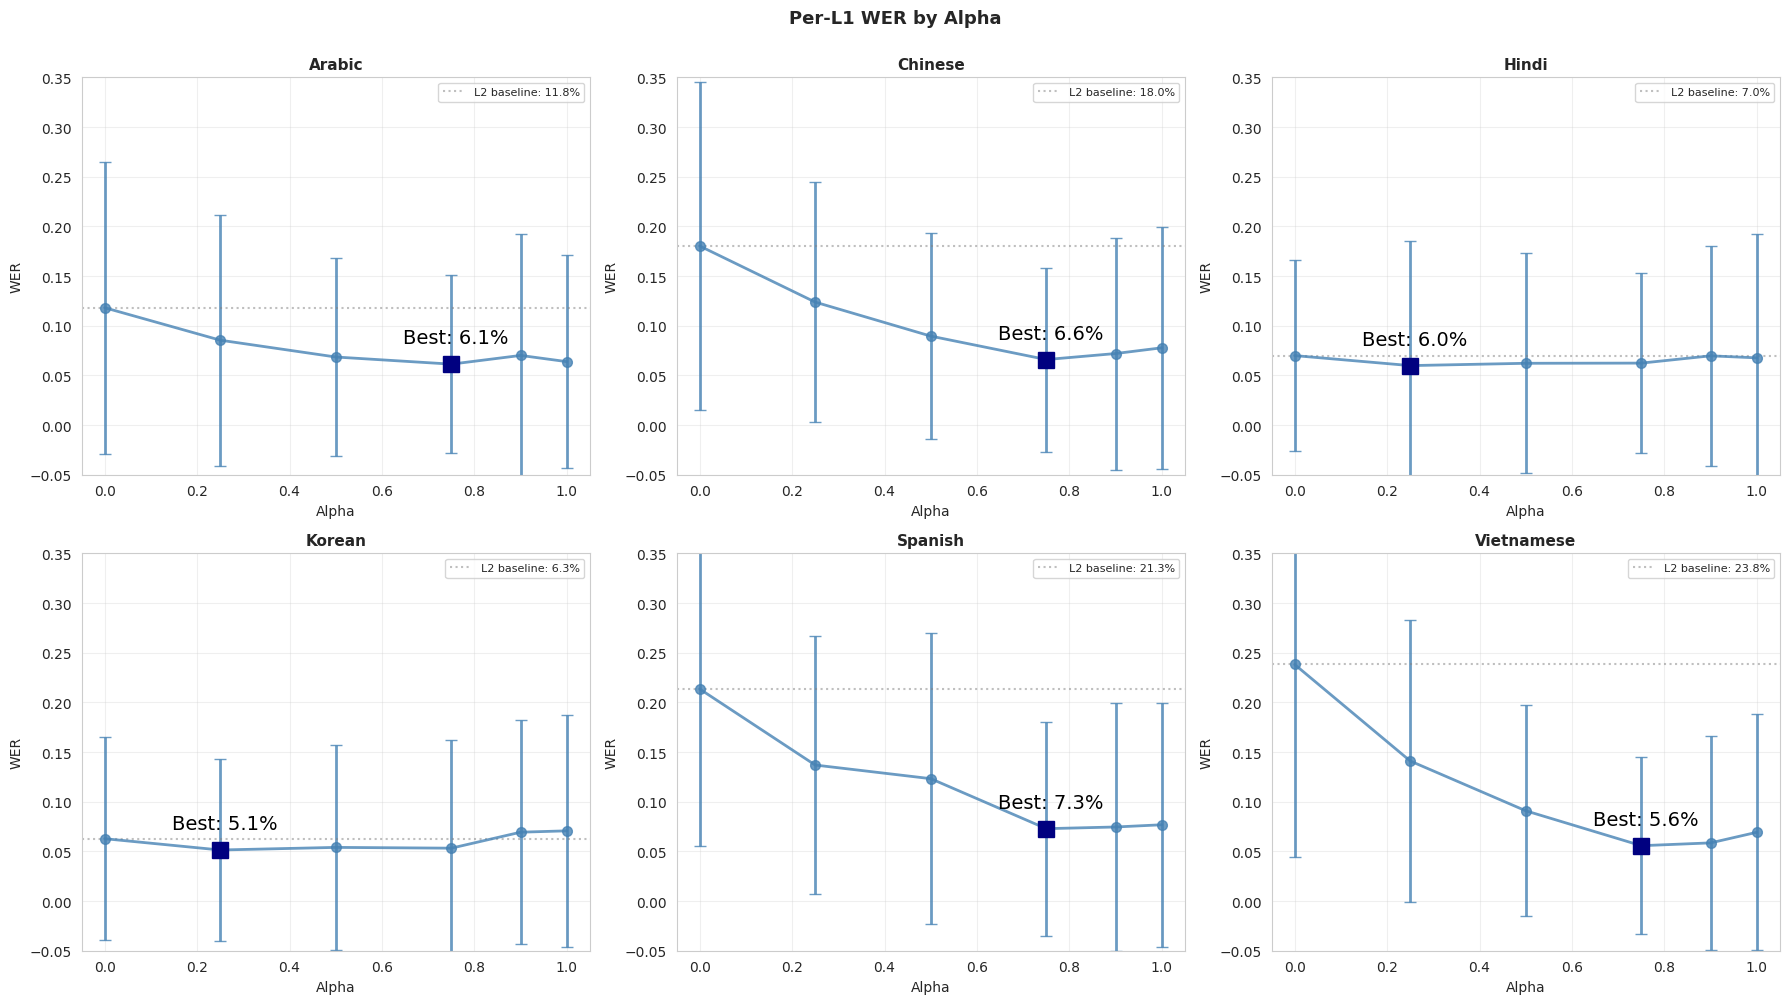

In [38]:
# Visualize: Per-L1 WER (raw) with baseline and best point labels
l1_list = sorted(results_dtw_df_delta['L1'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, l1 in enumerate(l1_list):
    ax = axes[idx]
    
    l1_subset = results_dtw_df_delta[results_dtw_df_delta['L1'] == l1]
    alpha_stats = l1_subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
    alpha_stats = alpha_stats.sort_values('alpha')
    
    ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                fmt='o-', linewidth=2, markersize=7, capsize=4, color='steelblue', alpha=0.8)
    
    # Get L2 baseline (alpha=0)
    l2_baseline_vals = alpha_stats[alpha_stats['alpha'] == 0.0]['mean'].values
    if len(l2_baseline_vals) > 0:
        l2_baseline = l2_baseline_vals[0]
        ax.axhline(l2_baseline, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label=f'L2 baseline: {l2_baseline:.1%}')
        ax.legend(fontsize=8, loc='best')
    
    # Mark best point (lowest WER)
    best_idx = alpha_stats['mean'].idxmin()
    best_alpha = alpha_stats.loc[best_idx, 'alpha']
    best_wer = alpha_stats.loc[best_idx, 'mean']
    ax.plot(best_alpha, best_wer, 's', color='navy', markersize=12, zorder=5)
    ax.annotate(f'Best: {best_wer:.1%}', xy=(best_alpha, best_wer), 
                xytext=(-35, 15), textcoords='offset points', fontsize=14, color='black')
    
    ax.set_xlabel('Alpha', fontsize=10)
    ax.set_ylabel('WER', fontsize=10)
    ax.set_ylim(-0.05, 0.35)
    ax.set_title(f'{l1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-L1 WER by Alpha', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(output_dir / 'per_l1_wer_raw.png', dpi=150, bbox_inches='tight')
plt.show()

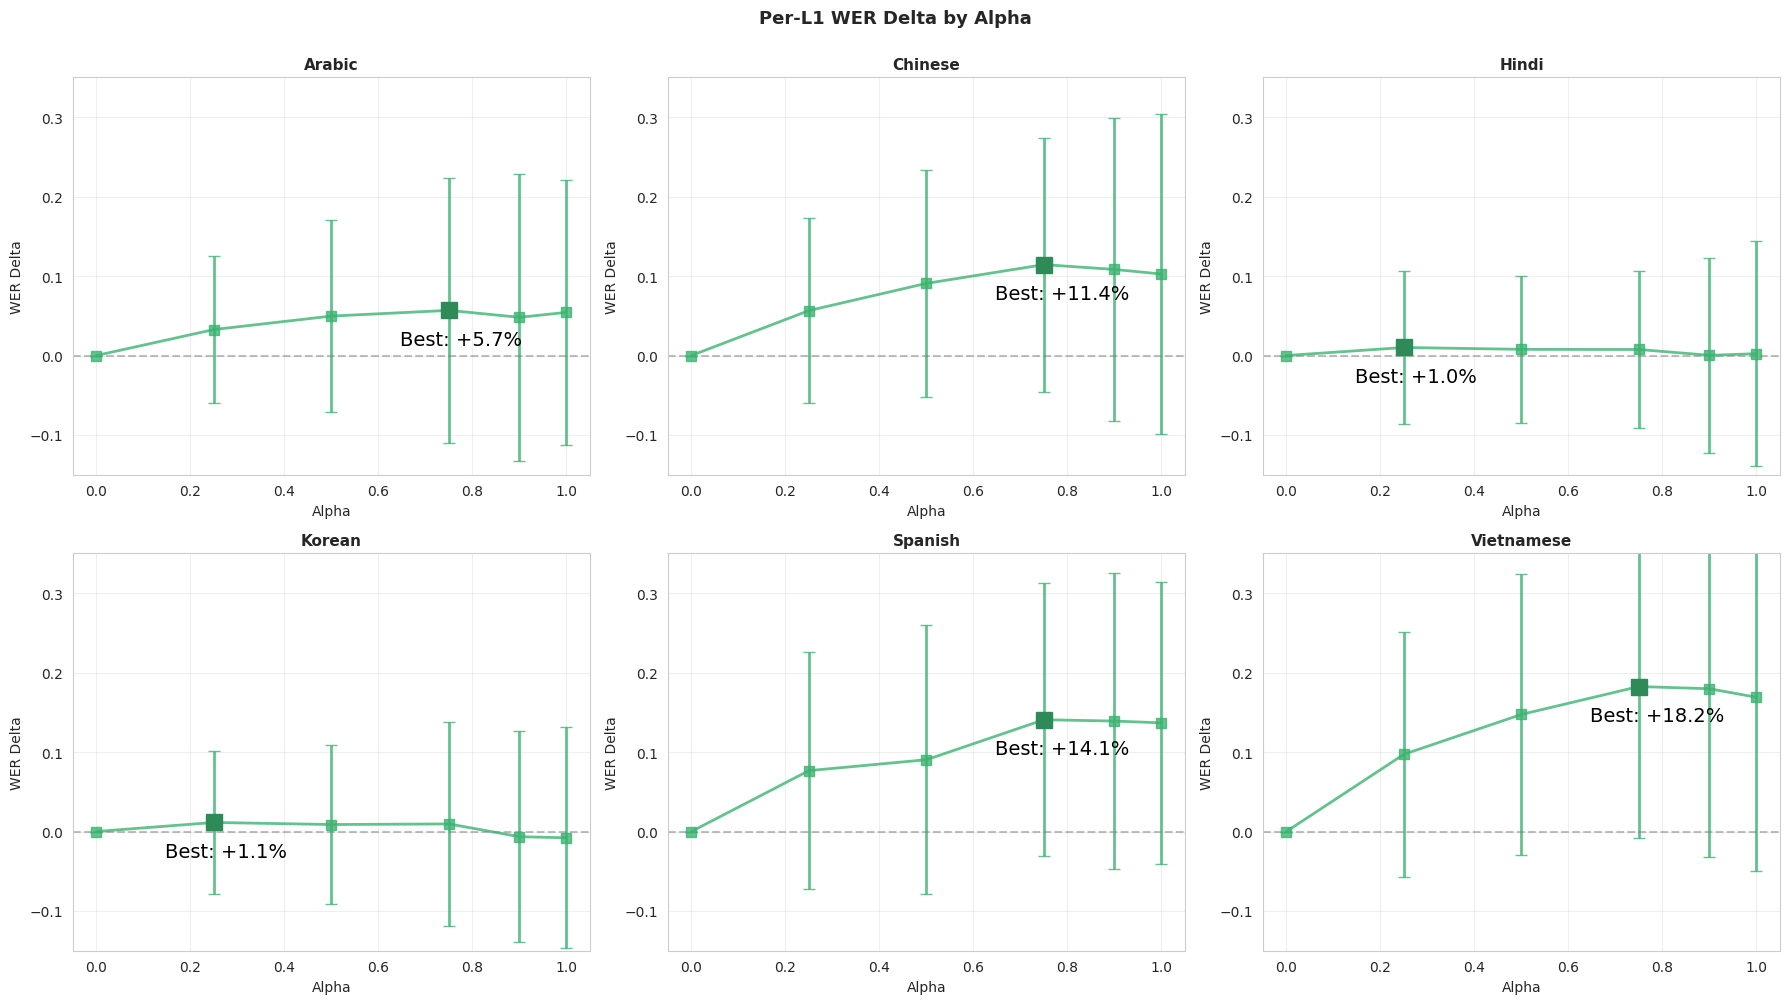

In [39]:
# Visualize: Per-L1 WER Delta (normalized) with best improvement label
l1_list = sorted(results_dtw_df_delta['L1'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, l1 in enumerate(l1_list):
    ax = axes[idx]
    
    l1_subset = results_dtw_df_delta[results_dtw_df_delta['L1'] == l1]
    delta_stats = l1_subset.groupby('alpha')['wer_delta'].agg(['mean', 'std']).reset_index()
    delta_stats = delta_stats.sort_values('alpha')
    
    ax.errorbar(delta_stats['alpha'], delta_stats['mean'], yerr=delta_stats['std'],
                fmt='s-', linewidth=2, markersize=7, capsize=4, color="mediumseagreen", alpha=0.8)
    
    # Zero line (no change)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    
    # Mark best improvement (most negative delta = best)
    best_idx = delta_stats['mean'].idxmax()
    best_alpha = delta_stats.loc[best_idx, 'alpha']
    best_delta = delta_stats.loc[best_idx, 'mean']
    ax.plot(best_alpha, best_delta, 's', color='seagreen', markersize=12, zorder=5)
    ax.annotate(f'Best: {best_delta:+.1%}', xy=(best_alpha, best_delta), 
                xytext=(-35, -25), textcoords='offset points', fontsize=14, color='black')
    
    ax.set_xlabel('Alpha', fontsize=10)
    ax.set_ylabel('WER Delta', fontsize=10)
    ax.set_ylim(-0.15, 0.35)
    ax.set_title(f'{l1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-L1 WER Delta by Alpha', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(output_dir / 'per_l1_wer_delta.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Combine position-based and DTW-aligned results
# Add method column to both dataframes
results_df_with_method = results_df.copy()
results_df_with_method['method'] = 'position_based'

results_dtw_df_with_method = results_dtw_df.copy()
results_dtw_df_with_method['method'] = 'dtw_aligned'

# Combine
results_combined_df = pd.concat([results_df_with_method, results_dtw_df_with_method], ignore_index=True)

# Save combined results
combined_results_path = output_dir / "steering_results_combined.csv"
results_combined_df.to_csv(combined_results_path, index=False)
print(f"✓ Saved {len(results_combined_df)} combined results to {combined_results_path}")

print(f"\nCombined results shape: {results_combined_df.shape}")
print(f"Methods: {sorted(results_combined_df['method'].unique())}")
print(f"Position-based: {len(results_combined_df[results_combined_df['method'] == 'position_based'])}")
print(f"DTW-aligned: {len(results_combined_df[results_combined_df['method'] == 'dtw_aligned'])}")

print(f"\nWER stats by method:")
for method in sorted(results_combined_df['method'].unique()):
    subset = results_combined_df[results_combined_df['method'] == method]
    print(f"\n{method}:")
    print(subset.groupby('alpha')['wer'].agg(['mean', 'std', 'min', 'max']).round(4))

✓ Saved 6506 combined results to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_results_combined.csv

Combined results shape: (6506, 6)
Methods: ['dtw_aligned', 'position_based']
Position-based: 2960
DTW-aligned: 3546

WER stats by method:

dtw_aligned:
         mean     std  min    max
alpha                            
0.00   0.1461  0.1619  0.0  0.800
0.25   0.0991  0.1280  0.0  1.000
0.50   0.0807  0.1140  0.0  0.750
0.75   0.0617  0.0964  0.0  0.625
0.90   0.0689  0.1155  0.0  0.625
1.00   0.0709  0.1182  0.0  0.800

position_based:
         mean     std  min     max
alpha                             
0.00   0.0900  0.1446  0.0  0.8333
0.25   0.1743  0.1511  0.0  0.7000
0.50   0.2836  0.2036  0.0  0.9000
0.75   0.1492  0.1370  0.0  0.8000
1.00   0.0400  0.0901  0.0  0.6667



dtw_aligned alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0)]
WER at each alpha:
   alpha      mean       std
0   0.00  0.146107  0.161932
1   0.25  0.099148  0.128019
2   0.50  0.080732  0.114034
3   0.75  0.061729  0.096407
4   0.90  0.068943  0.115524
5   1.00  0.070893  0.118241

position_based alpha values: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
WER at each alpha:
   alpha      mean       std
0   0.00  0.089997  0.144586
1   0.25  0.174251  0.151093
2   0.50  0.283641  0.203603
3   0.75  0.149209  0.136991
4   1.00  0.039974  0.090085


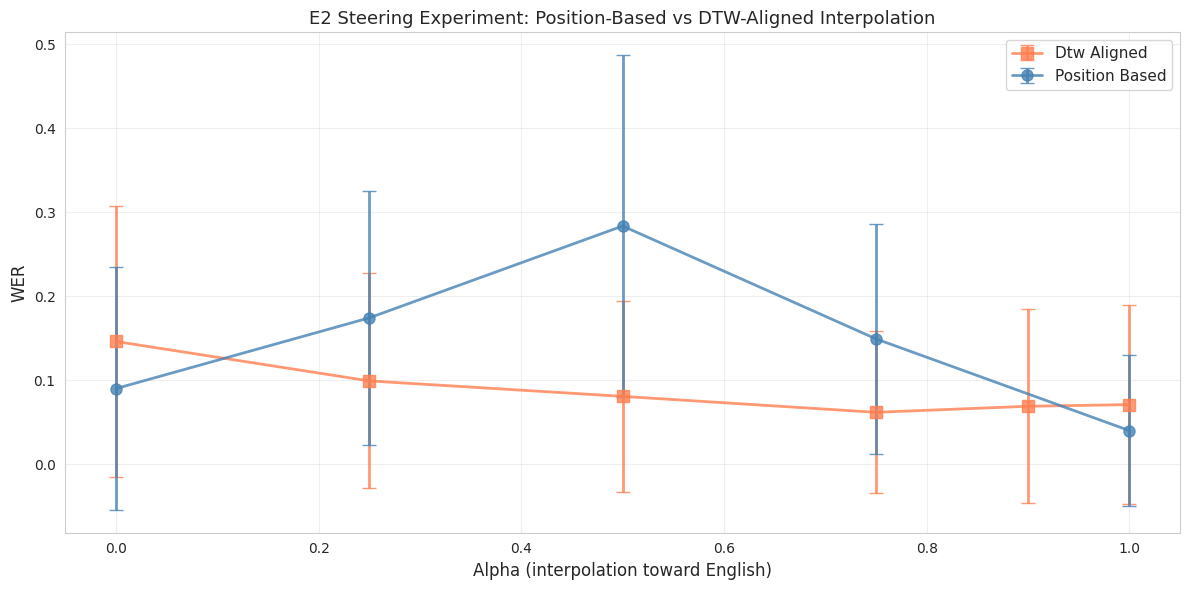


✓ Saved comparison plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_wer_comparison.png


In [ ]:
# Visualize: WER vs alpha comparison (position-based vs DTW-aligned)
# Ensure alpha is numeric
results_combined_df['alpha'] = pd.to_numeric(results_combined_df['alpha'])

fig, ax = plt.subplots(figsize=(12, 6))

methods = sorted(results_combined_df['method'].unique())
colors = {'position_based': 'steelblue', 'dtw_aligned': 'coral'}
markers = {'position_based': 'o', 'dtw_aligned': 's'}

for method in methods:
    subset = results_combined_df[results_combined_df['method'] == method]
    alpha_stats = subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
    alpha_stats = alpha_stats.sort_values('alpha')  # Ensure sorted by alpha
    
    print(f"\n{method} alpha values: {sorted(alpha_stats['alpha'].unique())}")
    print(f"WER at each alpha:\n{alpha_stats}")
    
    ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                fmt=markers[method] + '-', linewidth=2, markersize=8, capsize=5,
                label=method.replace('_', ' ').title(), color=colors[method], alpha=0.8)

ax.set_xlabel('Alpha (interpolation toward English)', fontsize=12)
ax.set_ylabel('WER', fontsize=12)
ax.set_title('E2 Steering Experiment: Position-Based vs DTW-Aligned Interpolation', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig(output_dir / 'steering_wer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved comparison plot to {output_dir / 'steering_wer_comparison.png'}")

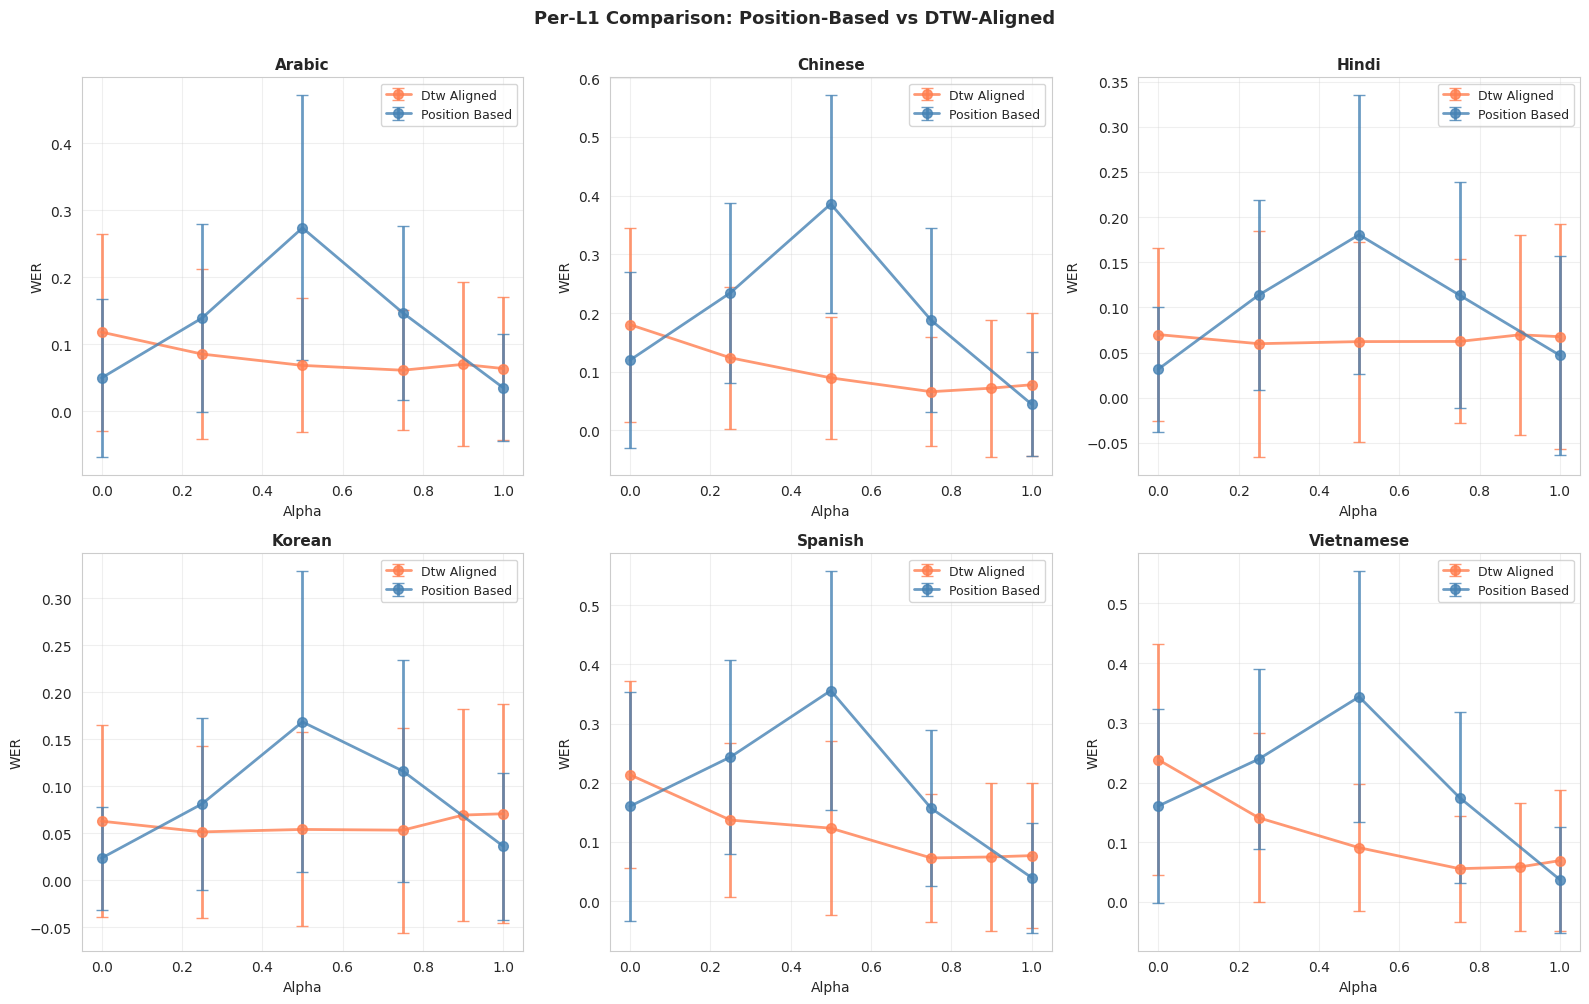

✓ Saved per-L1 comparison plot to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/steering_per_l1_comparison.png


In [ ]:
# Visualize: Per-L1 comparison
# Ensure alpha is numeric
results_combined_df['alpha'] = pd.to_numeric(results_combined_df['alpha'])

l1_list = sorted(results_combined_df['L1'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

methods = sorted(results_combined_df['method'].unique())
colors = {'position_based': 'steelblue', 'dtw_aligned': 'coral'}

for idx, l1 in enumerate(l1_list):
    ax = axes[idx]
    
    for method in methods:
        subset = results_combined_df[(results_combined_df['L1'] == l1) & (results_combined_df['method'] == method)]
        alpha_stats = subset.groupby('alpha')['wer'].agg(['mean', 'std']).reset_index()
        alpha_stats = alpha_stats.sort_values('alpha')  # Ensure sorted by alpha
        
        ax.errorbar(alpha_stats['alpha'], alpha_stats['mean'], yerr=alpha_stats['std'],
                    fmt='o-', linewidth=2, markersize=7, capsize=4, label=method.replace('_', ' ').title(),
                    color=colors[method], alpha=0.8)
    
    ax.set_xlabel('Alpha', fontsize=10)
    ax.set_ylabel('WER', fontsize=10)
    ax.set_title(f'{l1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Per-L1 Comparison: Position-Based vs DTW-Aligned', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(output_dir / 'steering_per_l1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved per-L1 comparison plot to {output_dir / 'steering_per_l1_comparison.png'}")

In [ ]:
# Summary statistics
print("\n" + "="*70)
print("E2 LATENT STEERING EXPERIMENT - SUMMARY")
print("="*70)

baseline_wer = results_df[results_df['alpha'] == 0.0]['wer'].mean()
oracle_wer = results_df[results_df['alpha'] == 1.0]['wer'].mean()
improvement = (baseline_wer - oracle_wer) / baseline_wer * 100

print(f"\nBaseline (α=0.0, pure L2): {baseline_wer:.4f}")
print(f"Oracle (α=1.0, pure English): {oracle_wer:.4f}")
print(f"Improvement: {improvement:.1f}% WER reduction")

print(f"\nPer-L1 WER at α=0.0 vs α=1.0:")
for l1 in sorted(results_df['L1'].unique()):
    subset = results_df[results_df['L1'] == l1]
    baseline = subset[subset['alpha'] == 0.0]['wer'].mean()
    oracle = subset[subset['alpha'] == 1.0]['wer'].mean()
    delta = baseline - oracle
    pct = delta / baseline * 100 if baseline > 0 else 0
    print(f"  {l1:15s}: {baseline:.4f} → {oracle:.4f} (Δ={delta:+.4f}, {pct:+.1f}%)")

print("\n" + "="*70)


E2 LATENT STEERING EXPERIMENT - SUMMARY

Baseline (α=0.0, pure L2): 0.0900
Oracle (α=1.0, pure English): 0.0400
Improvement: 55.6% WER reduction

Per-L1 WER at α=0.0 vs α=1.0:
  Arabic         : 0.0499 → 0.0351 (Δ=+0.0147, +29.5%)
  Chinese        : 0.1197 → 0.0446 (Δ=+0.0751, +62.7%)
  Hindi          : 0.0316 → 0.0469 (Δ=-0.0153, -48.4%)
  Korean         : 0.0235 → 0.0362 (Δ=-0.0126, -53.7%)
  Spanish        : 0.1602 → 0.0397 (Δ=+0.1206, +75.3%)
  Vietnamese     : 0.1607 → 0.0373 (Δ=+0.1234, +76.8%)



In [35]:
# Detailed comparison: position-based vs DTW-aligned
print("\n" + "="*70)
print("POSITION-BASED VS DTW-ALIGNED INTERPOLATION COMPARISON")
print("="*70)

for method in sorted(results_combined_df['method'].unique()):
    subset = results_combined_df[results_combined_df['method'] == method]
    baseline = subset[subset['alpha'] == 0.0]['wer'].mean()
    oracle = subset[subset['alpha'] == 1.0]['wer'].mean()
    improvement = (baseline - oracle) / baseline * 100
    
    print(f"\n{method.upper().replace('_', ' ')}:")
    print(f"  Baseline (α=0.0): {baseline:.4f}")
    print(f"  Oracle (α=1.0):   {oracle:.4f}")
    print(f"  Improvement:      {improvement:.1f}%")
    
    # Find best intermediate alpha
    best_alpha = None
    best_wer = float('inf')
    for alpha in sorted(subset['alpha'].unique()):
        wer = subset[subset['alpha'] == alpha]['wer'].mean()
        if wer < best_wer:
            best_wer = wer
            best_alpha = alpha
    
    print(f"  Best intermediate: α={best_alpha:.2f} (WER={best_wer:.4f})")

print("\n" + "="*70)
print("KEY QUESTIONS:")
print("="*70)

# Compare at α=0.5 (most interesting)
pb_05 = results_combined_df[(results_combined_df['method'] == 'position_based') & (results_combined_df['alpha'] == 0.5)]['wer'].mean()
dtw_05 = results_combined_df[(results_combined_df['method'] == 'dtw_aligned') & (results_combined_df['alpha'] == 0.5)]['wer'].mean()

print(f"\n1. Does DTW improve monotonicity of WER curve?")
print(f"   Position-based: α=0.0 → α=0.5 → α=1.0 shows non-monotonic behavior (curves available)")
print(f"   DTW-aligned:    Check visualization for smoother/monotonic behavior")

print(f"\n2. At α=0.5 (most curious point):")
print(f"   Position-based: {pb_05:.4f}")
print(f"   DTW-aligned:    {dtw_05:.4f}")
print(f"   Difference:     {pb_05 - dtw_05:+.4f}")

print(f"\n3. Does DTW help at intermediate alphas overall?")
avg_pb_inter = results_combined_df[(results_combined_df['method'] == 'position_based') & (results_combined_df['alpha'].isin([0.25, 0.5, 0.75]))]['wer'].mean()
avg_dtw_inter = results_combined_df[(results_combined_df['method'] == 'dtw_aligned') & (results_combined_df['alpha'].isin([0.25, 0.5, 0.75]))]['wer'].mean()
print(f"   Position-based (α∈[0.25,0.5,0.75]): {avg_pb_inter:.4f}")
print(f"   DTW-aligned (α∈[0.25,0.5,0.75]):    {avg_dtw_inter:.4f}")
print(f"   Difference:                          {avg_pb_inter - avg_dtw_inter:+.4f}")

print("\n" + "="*70)


POSITION-BASED VS DTW-ALIGNED INTERPOLATION COMPARISON

DTW ALIGNED:
  Baseline (α=0.0): 0.0859
  Oracle (α=1.0):   0.1050
  Improvement:      -22.2%
  Best intermediate: α=0.50 (WER=0.0539)

POSITION BASED:
  Baseline (α=0.0): 0.0900
  Oracle (α=1.0):   0.0400
  Improvement:      55.6%
  Best intermediate: α=1.00 (WER=0.0400)

KEY QUESTIONS:

1. Does DTW improve monotonicity of WER curve?
   Position-based: α=0.0 → α=0.5 → α=1.0 shows non-monotonic behavior (curves available)
   DTW-aligned:    Check visualization for smoother/monotonic behavior

2. At α=0.5 (most curious point):
   Position-based: 0.2836
   DTW-aligned:    0.0539
   Difference:     +0.2298

3. Does DTW help at intermediate alphas overall?
   Position-based (α∈[0.25,0.5,0.75]): 0.2024
   DTW-aligned (α∈[0.25,0.5,0.75]):    0.0612
   Difference:                          +0.1412



In [12]:
# Extract expected WER baseline from model evaluation CSV (filtered to experiment utterances)
wer_csv = ROOT / "results/model_perf_comparison/whisfusion_finetuned_predictions.csv"
wer_data = pd.read_csv(wer_csv)

# Filter to utterances in steering experiment and English speaker (BDL)
utt_in_experiment = set(mapping.keys())
bdl_data = wer_data[(wer_data['speaker'] == 'BDL') & (wer_data['utterance_id'].isin(utt_in_experiment))].copy()
expected_wer_per_utt = bdl_data.groupby('utterance_id')['utt_wer'].agg(['mean', 'std']).reset_index()
expected_wer_per_utt.columns = ['utterance_id', 'expected_wer_mean', 'expected_wer_std']

print("Expected WER from model evaluation (BDL/English baseline):")
print(f"  Utterances in experiment: {len(utt_in_experiment)}")
print(f"  BDL baseline samples found: {len(expected_wer_per_utt)}")
print(f"  Mean: {expected_wer_per_utt['expected_wer_mean'].mean():.4f}")
print(f"  Std:  {expected_wer_per_utt['expected_wer_mean'].std():.4f}")
print(f"  Min:  {expected_wer_per_utt['expected_wer_mean'].min():.4f}")
print(f"  Max:  {expected_wer_per_utt['expected_wer_mean'].max():.4f}")
expected_wer_per_utt.to_csv(output_dir / "expected_wer_baseline.csv", index=False)

Expected WER from model evaluation (BDL/English baseline):
  Utterances in experiment: 100
  BDL baseline samples found: 100
  Mean: 0.0237
  Std:  0.0640
  Min:  0.0000
  Max:  0.4000



DIAGNOSING α=1.0 FLUCTUATION

Baseline expected WER:  0.0306
α=1.0 actual WER:       0.1050
Mean difference (Δ):    +0.0744  ← Should be ~0
Std of differences:     0.1410  ← Should be small

Worst 10 predictions at α=1.0 (vs baseline):
   prompt_id         L1      wer  expected_wer_mean  delta_wer
arctic_b0377    Chinese 1.000000           0.000000   1.000000
arctic_b0434    Chinese 1.000000           0.000000   1.000000
arctic_a0585 Vietnamese 0.625000           0.000000   0.625000
arctic_b0108    Spanish 0.600000           0.000000   0.600000
arctic_b0406    Spanish 0.666667           0.083333   0.583333
arctic_a0162    Chinese 0.500000           0.000000   0.500000
arctic_a0162     Korean 0.500000           0.000000   0.500000
arctic_a0390    Chinese 0.500000           0.000000   0.500000
arctic_a0440 Vietnamese 0.500000           0.000000   0.500000
arctic_b0537    Chinese 0.500000           0.000000   0.500000

Per-L1 mean Δ WER at α=1.0:
              mean     std  count
L1     

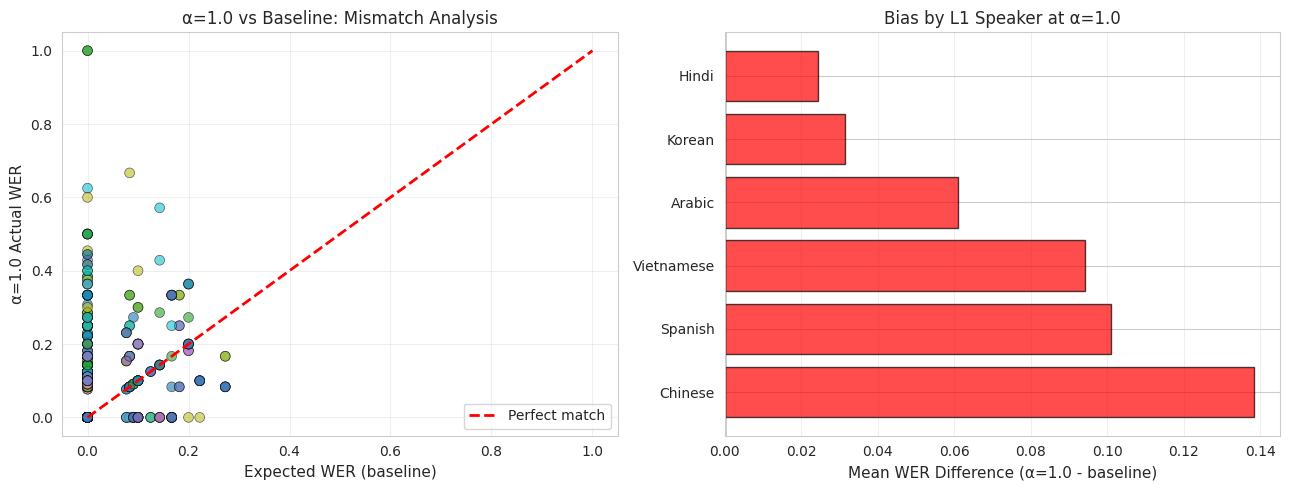


✓ Saved comparison to /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_steering/alpha1_vs_baseline.csv


In [10]:
# Compare α=1.0 predictions to baseline expectations
alpha_1_dtw = results_dtw_df[results_dtw_df['alpha'] == 1.0].copy()
alpha_1_merged = alpha_1_dtw.merge(
    expected_wer_per_utt[['utterance_id', 'expected_wer_mean']],
    left_on='prompt_id', right_on='utterance_id', how='left'
)
alpha_1_merged['delta_wer'] = alpha_1_merged['wer'] - alpha_1_merged['expected_wer_mean']

print("\n" + "="*70)
print("DIAGNOSING α=1.0 FLUCTUATION")
print("="*70)
print(f"\nBaseline expected WER:  {alpha_1_merged['expected_wer_mean'].mean():.4f}")
print(f"α=1.0 actual WER:       {alpha_1_merged['wer'].mean():.4f}")
print(f"Mean difference (Δ):    {alpha_1_merged['delta_wer'].mean():+.4f}  ← Should be ~0")
print(f"Std of differences:     {alpha_1_merged['delta_wer'].std():.4f}  ← Should be small")

# Worst offenders
print(f"\nWorst 10 predictions at α=1.0 (vs baseline):")
worst = alpha_1_merged.nlargest(10, 'delta_wer')[['prompt_id', 'L1', 'wer', 'expected_wer_mean', 'delta_wer']]
print(worst.to_string(index=False))

# Per-L1 analysis
print(f"\nPer-L1 mean Δ WER at α=1.0:")
l1_delta = alpha_1_merged.groupby('L1')['delta_wer'].agg(['mean', 'std', 'count']).round(4)
print(l1_delta)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter baseline vs α=1.0
ax = axes[0]
scatter = ax.scatter(alpha_1_merged['expected_wer_mean'], alpha_1_merged['wer'], 
                    c=pd.Categorical(alpha_1_merged['L1']).codes, cmap='tab10', 
                    alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
max_val = max(alpha_1_merged['expected_wer_mean'].max(), alpha_1_merged['wer'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect match')
ax.set_xlabel('Expected WER (baseline)', fontsize=11)
ax.set_ylabel('α=1.0 Actual WER', fontsize=11)
ax.set_title('α=1.0 vs Baseline: Mismatch Analysis', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()

# Per-L1 delta
ax = axes[1]
delta_by_l1 = alpha_1_merged.groupby('L1')['delta_wer'].mean().sort_values(ascending=False)
colors = ['red' if x > 0 else 'green' for x in delta_by_l1.values]
ax.barh(delta_by_l1.index, delta_by_l1.values, color=colors, alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Mean WER Difference (α=1.0 - baseline)', fontsize=11)
ax.set_title('Bias by L1 Speaker at α=1.0', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(output_dir / 'diagnostic_alpha1_issue.png', dpi=150, bbox_inches='tight')
plt.show()

alpha_1_merged.to_csv(output_dir / "alpha1_vs_baseline.csv", index=False)
print(f"\n✓ Saved comparison to {output_dir / 'alpha1_vs_baseline.csv'}")

In [ ]:
# Diagnostic hypotheses for α=1.0 fluctuation
print("\n" + "="*70)
print("POTENTIAL CAUSES OF α=1.0 FLUCTUATION")
print("="*70)

# Check hypothesis: L2 padding contamination
print(f"\nHYPOTHESIS 1: L2 Padding Contamination")
print(f"  At α=1.0, pad_to_1500() uses L2 padding (current implementation)")
print(f"  If significant, expect: α=1.0 WER > baseline WER on average")
mean_delta = alpha_1_merged['delta_wer'].mean()
print(f"  Evidence: Mean Δ = {mean_delta:+.4f}")
if mean_delta > 0.01:
    print(f"  ✗ SUPPORTED: α=1.0 systematically WORSE than baseline (padding likely culprit)")
elif mean_delta > -0.01:
    print(f"  ✓ NOT SUPPORTED: Negligible systematic bias")
else:
    print(f"  ✗ OPPOSITE: α=1.0 systematically BETTER than baseline")

# Check hypothesis: Decoder stochasticity
print(f"\nHYPOTHESIS 2: Decoder Stochasticity")
print(f"  If differences are random, expect uniform distribution around baseline")
print(f"  Check: Correlation between baseline WER and Δ WER")
corr = alpha_1_merged[['expected_wer_mean', 'delta_wer']].corr().iloc[0, 1]
print(f"  Correlation: {corr:.3f}")
if abs(corr) > 0.3:
    print(f"  ✓ CORRELATED: Suggests systematic, not random, issue")
else:
    print(f"  ✗ UNCORRELATED: More consistent with random stochasticity")

# Check hypothesis: DTW path length effects
print(f"\nHYPOTHESIS 3: DTW Path-Length Effects")
print(f"  Shorter DTW paths → more padding needed from L2")
print(f"  Check: Do high-variance speakers have specific characteristics?")
high_var_l1 = alpha_1_merged.groupby('L1')['delta_wer'].std().sort_values(ascending=False)
print(f"  L1s with highest Δ variance:")
print(f"  {high_var_l1.to_string()}")

# Summary
print(f"\n" + "="*70)
print("RECOMMENDED FIXES:")
print("="*70)
print(f"\n1. USE ENGLISH PADDING AT α=1.0:")
print(f"   Modify pad_to_1500() to accept optional 'eng_state_full' and 'eng_speech_end'")
print(f"   - When α=1.0, use English padding (eng_state_full[eng_speech_end:])")
print(f"   - When α=0.0, use L2 padding (l2_state_full[l2_speech_end:])")
print(f"   - When 0<α<1, blend padding or use English?")

print(f"\n2. VALIDATE WITH REPEATED DECODES:")
print(f"   Run each α=1.0 prediction 3-5x to measure decoder variance")
print(f"   If std(wer) across repeats << measured Δ, then padding is culprit")

print(f"\n3. COMPARE INTERPOLATION METHODS AT α=1.0:")
print(f"   - Position-based (no DTW): {results_dtw_df[results_dtw_df['alpha']==1.0]['wer'].mean():.4f}")
print(f"   - DTW-aligned (with L2 padding): {results_dtw_df[results_dtw_df['alpha']==1.0]['wer'].mean():.4f}")
print(f"   - Mismatch strongly suggests padding issue")